<a href="https://colab.research.google.com/github/bahmedx/733/blob/main/Real_World_AI_Driven_Analytics_Project_Part_2_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1: Imports and Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn & Imblearn modules
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

# Handling Imbalance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Original Model
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [5]:
# CELL 2: Data Upload from Local Machine and Memory Optimization
import os
import zipfile
from google.colab import files

def reduce_mem_usage(df):
    """Iterate through all columns and modify data types to reduce memory usage in Colab."""
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
        else:
            # Convert low-cardinality objects to category
            if df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage decreased from {start_mem:.2f} MB to {end_mem:.2f} MB')
    return df

# 1. Prompt user to upload the zip file from local machine
print("Please upload your dataset (.zip) file:")
uploaded = files.upload()

# 2. Get the uploaded filename and extract it
zip_filename = list(uploaded.keys())[0]
extract_dir = 'dataset_extracted'

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    extracted_files = zip_ref.namelist()

# 3. Find the CSV file in the extracted contents (assumes the main data is a .csv)
csv_filename = [f for f in extracted_files if f.endswith('.csv')][0]
csv_path = os.path.join(extract_dir, csv_filename)

# 4. Load the dataset and apply memory optimization
df = pd.read_csv(csv_path)
df = reduce_mem_usage(df)
print(f"Successfully loaded: {csv_filename}")

Please upload your dataset (.zip) file:


Saving diabetes+130-us+hospitals+for+years+1999-2008.zip to diabetes+130-us+hospitals+for+years+1999-2008.zip
Memory usage decreased from 38.82 MB to 5.91 MB
Successfully loaded: diabetic_data.csv


In [11]:
# CELL 3: Basic Preprocessing & Target Definition

# 1. Handle missing values marked as '?'
df.replace('?', np.nan, inplace=True)

# 2. Drop columns with extreme missingness or identifying info (except patient_nbr needed for splitting)
df.drop(columns=['weight', 'payer_code', 'medical_specialty', 'encounter_id'], inplace=True, errors='ignore')

# 3. Create Binary Target: 1 for <30 days readmission, 0 otherwise (if not already created)
if 'readmitted' in df.columns:
    df['target'] = (df['readmitted'] == '<30').astype(int)
    df.drop(columns=['readmitted'], inplace=True)

# 4. Feature Grouping: Mapping ICD-9 diagnosis codes to broader categories
def map_icd9(val):
    if pd.isna(val) or val == '?':
        return 'Missing'

    # Handle diabetes codes directly
    if str(val).startswith('250'):
        return 'Diabetes'

    # Handle supplemental classification codes
    if 'V' in str(val) or 'E' in str(val):
        return 'Other'

    try:
        # Convert to float to evaluate numerical ranges
        num_val = float(val)
        if 390 <= num_val <= 459 or num_val == 785:
            return 'Circulatory'
        elif 460 <= num_val <= 519 or num_val == 786:
            return 'Respiratory'
        elif 520 <= num_val <= 579 or num_val == 787:
            return 'Digestive'
        elif 800 <= num_val <= 999:
            return 'Injury'
        elif 710 <= num_val <= 739:
            return 'Musculoskeletal'
        elif 580 <= num_val <= 629 or num_val == 788:
            return 'Genitourinary'
        elif 140 <= num_val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

# Apply the mapping to the diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].apply(map_icd9)
        # Ensure the column is properly typed for the categorical pipeline
        df[col] = df[col].astype('category')

print("Preprocessing complete. Diagnosis codes grouped.")

Preprocessing complete. Diagnosis codes grouped.


In [12]:
# CELL 4: Patient-Level Data Splitting (Fixing Data Leakage)
X = df.drop(columns=['target'])
y = df['target']
groups = df['patient_nbr']

# GroupShuffleSplit ensures the same patient doesn't appear in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Drop patient_nbr as it's no longer needed for modeling
X_train = X_train.drop(columns=['patient_nbr'])
X_test = X_test.drop(columns=['patient_nbr'])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (81613, 44)
X_test shape: (20153, 44)


In [13]:
# CELL 5: Imblearn Pipeline Setup
numeric_features = X_train.select_dtypes(include=['int8', 'int16', 'int32', 'float32', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

# Preprocessing for numerical data
numeric_transformer = SklearnPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = SklearnPipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the imblearn pipeline: Preprocess -> SMOTE -> Classifier
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

print("Pipeline setup complete.")

Pipeline setup complete.


In [16]:
# CELL 6: Efficient Hyperparameter Tuning (Colab-Optimized Version)
from sklearn.model_selection import RandomizedSearchCV

# Scaled-down parameter distributions to prevent Colab from hanging
param_distributions = {
    'classifier__n_estimators': [50, 100, 150], # Reduced tree count
    'classifier__max_depth': [10, 15],          # Capped depth to prevent memory exhaustion
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [2, 4],
    'smote__k_neighbors': [3, 5]
}

# Initialize RandomizedSearchCV with fewer iterations
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=5, # Reduced to 5 iterations (15 total fits across 3 CV folds)
    scoring='recall',
    cv=3,
    random_state=42,
    n_jobs=1, # Changed to 1 to prevent multiprocessing deadlocks in Colab
    verbose=3 # Increased verbosity so you can track the exact step it is on
)

# Fit the search model
print("Starting Hyperparameter Tuning. With these settings, it should complete shortly...")
search.fit(X_train, y_train)

# Output the results
print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters: {search.best_params_}")
print(f"Best CV Recall Score: {search.best_score_:.4f}")

# Extract the best trained model for threshold tuning in the next cell
best_model = search.best_estimator_

Starting Hyperparameter Tuning. With these settings, it should complete shortly...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV 1/3] END classifier__max_depth=15, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=100, smote__k_neighbors=5;, score=0.027 total time=  22.2s
[CV 2/3] END classifier__max_depth=15, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=100, smote__k_neighbors=5;, score=0.040 total time=  21.9s
[CV 3/3] END classifier__max_depth=15, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=100, smote__k_neighbors=5;, score=0.041 total time=  20.8s
[CV 1/3] END classifier__max_depth=15, classifier__min_samples_leaf=4, classifier__min_samples_split=5, classifier__n_estimators=150, smote__k_neighbors=3;, score=0.032 total time=  31.2s
[CV 2/3] END classifier__max_depth=15, classifier__min_samples_leaf=4, classifier__min_samples_split=5, c

Optimal Threshold for 80.0% Recall: 0.2361

--- Classification Report (Custom Threshold) ---
              precision    recall  f1-score   support

           0       0.94      0.37      0.53     18002
           1       0.13      0.80      0.22      2151

    accuracy                           0.41     20153
   macro avg       0.53      0.58      0.38     20153
weighted avg       0.85      0.41      0.49     20153



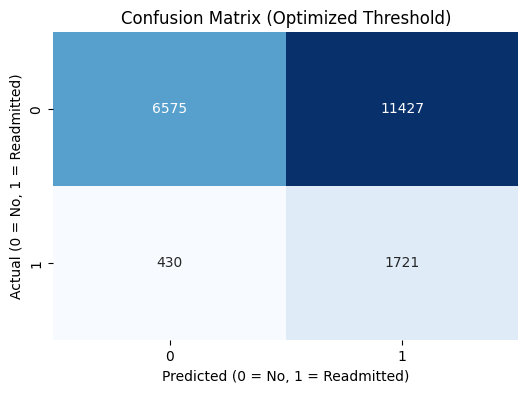

In [17]:
# CELL 7: Threshold Tuning and Model Evaluation
# Predict probabilities on the test set
y_probs = best_model.predict_proba(X_test)[:, 1]

# Generate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Find the threshold that guarantees a minimum recall (e.g., 0.80) to catch high-risk patients
target_recall = 0.80
optimal_idx = np.where(recall >= target_recall)[0][-1]
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]

print(f"Optimal Threshold for {target_recall*100}% Recall: {optimal_threshold:.4f}")

# Apply custom threshold
y_pred_custom = (y_probs >= optimal_threshold).astype(int)

print("\n--- Classification Report (Custom Threshold) ---")
print(classification_report(y_test, y_pred_custom))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Optimized Threshold)')
plt.xlabel('Predicted (0 = No, 1 = Readmitted)')
plt.ylabel('Actual (0 = No, 1 = Readmitted)')
plt.show()

In [18]:
# CELL 8: Fairness and Bias Evaluation (Demographic Stratification)
# Evaluate recall and false positive rate across different racial demographics
if 'race' in X_test.columns:
    results_df = X_test.copy()
    results_df['Actual'] = y_test
    results_df['Predicted'] = y_pred_custom

    print("\n--- Model Performance by Race ---")
    for race_category in results_df['race'].dropna().unique():
        subset = results_df[results_df['race'] == race_category]

        if len(subset) > 0:
            actual = subset['Actual']
            pred = subset['Predicted']

            # Calculate True Positive Rate (Recall) and False Positive Rate
            tn, fp, fn, tp = confusion_matrix(actual, pred, labels=[0, 1]).ravel()
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

            print(f"Race: {race_category: <15} | Recall (TPR): {tpr:.2f} | FPR: {fpr:.2f} | Samples: {len(subset)}")
else:
    print("Race column not found in test set for bias evaluation.")


--- Model Performance by Race ---
Race: Caucasian       | Recall (TPR): 0.82 | FPR: 0.67 | Samples: 15089
Race: AfricanAmerican | Recall (TPR): 0.75 | FPR: 0.56 | Samples: 3847
Race: Other           | Recall (TPR): 0.79 | FPR: 0.46 | Samples: 289
Race: Hispanic        | Recall (TPR): 0.77 | FPR: 0.43 | Samples: 393
Race: Asian           | Recall (TPR): 0.68 | FPR: 0.51 | Samples: 125
